# 第66篇 | 高阶导数与Hessian矩阵：函数的「曲率」

> **摘要**：一阶导数告诉你函数「往哪走」，二阶导数告诉你「走得有多快」（曲率）。本篇系统讲解高阶偏导数的计算、Hessian矩阵的定义与性质、正定/负定/不定的判定，以及Hessian在优化算法（牛顿法）中的核心作用。

嗨，我是小荷～ 上篇我们讲了链式法则和反向传播。今天聊一个更「深层」的话题：如果我对导数再求一次导，会怎么样？答案就是**二阶导数**——它揭示了函数的「曲率」或「弯曲程度」。在优化算法中，Hessian矩阵（二阶偏导数的集合）决定了牛顿法比梯度下降快多少。

---

## 一、高阶导数：从「变化率」到「变化率的变化率」

如果说导数是你在开车时看一眼时速表（速度），那么高阶导数（Higher-Order Derivatives）就是用来记录这场速度变幻的“连环套娃监测仪”。

在机器学习（比如优化高阶损失函数、玩转 Hessian 矩阵）和物理学中，高阶导数能帮你捕捉到数据最细微的趋势之趋势。

- 一阶导数 f'(x)：函数值的**变化率**（速度）
- 二阶导数 f''(x)：一阶导数的**变化率**（加速度），就是你踩油门的狠劲。如果你猛踩油门，速度从 100 瞬间飙到 120，这就是正的加速度；如果你踩刹车，速度直线下降，这就是负的加速度。它反映了速度的变化快慢。
- 三阶导数 f'''(x)：就是你踩油门那只脚的变动频率。你是温柔地、平滑地逐渐把油门踩到底（三阶导数很小，坐车很舒服），还是像发疯一样一脚死踩一脚猛放（三阶导数极大，乘客会直接吐出来）。它反映了推背感（加速度）的变化快慢。

**代码演示**
1. 原函数 f(x) = x³ - 3x，三次多项式曲线，纵坐标代表函数取值。
2. 一阶导数 f'(x) = 3x² - 3，代表原函数在x处的瞬时变化率（切线斜率）
   - f'(x)>0：原函数切线向上倾斜，f(x) 单调递增；
   - f'(x)<0：原函数切线向下倾斜，f(x) 单调递减；
   - f'(x)=0：原函数极值点（波峰 / 波谷）。x=1 时 f'(x)=0，对应 f(x) 的极大、极小值点。
4. 二阶导数 f''(x) = 6x，代表一阶导数的变化率，对应原函数曲线曲率凹凸性
   - f''(x)>0（x>0）：一阶导数 f'(x) 持续变大，原函数凹向上（下凸）；
   - f''(x)<0（x<0）：一阶导数 f'(x) 持续变小，原函数凸向上（上凸）；
   - f''(x)=0（x=0）：凹凸切换点，称为拐点。

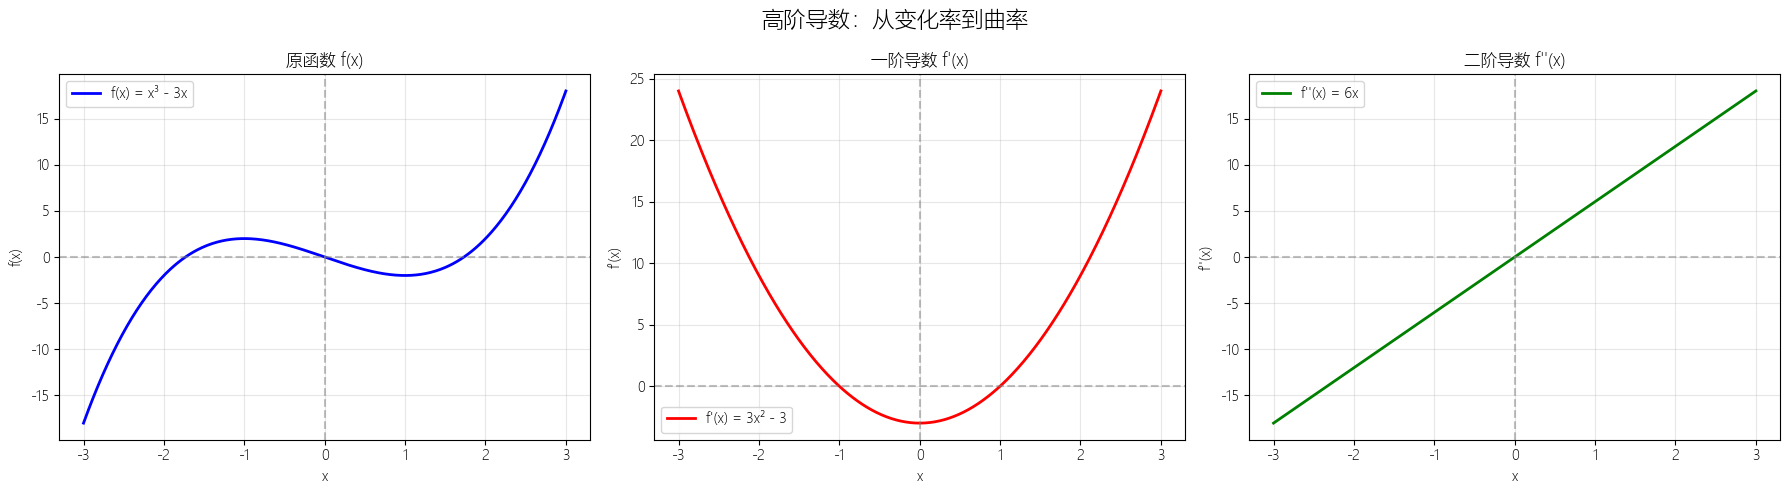

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== 绘图全局字体配置（解决中文、数学∇符号缺失报错） ======================
# 设置绘图中文显示字体优先级：微软雅黑→黑体→数学专用DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示为方框方块的bug
plt.rcParams['axes.unicode_minus'] = False
# 单独配置数学公式渲染字体，内置导数、梯度、积分等符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'

def f(x):
    """原函数 f(x) = x³ - 3x，三次多项式曲线"""
    return x**3 - 3*x

def f_prime(x):
    """一阶导数 f'(x) = 3x² - 3，代表原函数在x处的瞬时变化率（切线斜率）"""
    return 3*x**2 - 3

def f_double_prime(x):
    """二阶导数 f''(x) = 6x，代表一阶导数的变化率，对应原函数曲线曲率凹凸性"""
    return 6*x

# 生成[-3,3]区间内500个均匀采样点，曲线绘制更平滑
x_range = np.linspace(-3, 3, 500)

# 创建画布：1行3个子图，总尺寸宽18高5英寸
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------- 左子图：原函数 f(x) ----------------------
axes[0].plot(x_range, f(x_range), 'b-', lw=2, label="f(x) = x³ - 3x")
# 绘制水平虚线y=0（x轴基准线）
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# 绘制垂直虚线x=0（y轴基准线）
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('原函数 f(x)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].grid(True, alpha=0.3) # 开启浅灰色网格辅助观察坐标
axes[0].legend() # 显示曲线图例

# ---------------------- 中子图：一阶导数 f'(x) ----------------------
axes[1].plot(x_range, f_prime(x_range), 'r-', lw=2, label="f'(x) = 3x² - 3")
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title("一阶导数 f'(x)")
axes[1].set_xlabel('x')
axes[1].set_ylabel("f'(x)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# ---------------------- 右子图：二阶导数 f''(x) ----------------------
axes[2].plot(x_range, f_double_prime(x_range), 'g-', lw=2, label="f''(x) = 6x")
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title("二阶导数 f''(x)")
axes[2].set_xlabel('x')
axes[2].set_ylabel("f''(x)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# 设置总标题
plt.suptitle('高阶导数：从变化率到曲率', fontsize=16)
# 自动调整子图间距，防止标题、坐标轴文字重叠遮挡
plt.tight_layout()
# 弹出绘图窗口展示图像
plt.show()

这段可视化代码展示了导数的层级关系——一阶导数决定了函数的“增减与极值”，二阶导数决定了函数的“曲率与凹凸”。它们共同构成了我们全面理解函数形态和优化算法的数学基石。

---

## 二、多变量情况：Hessian矩阵

如果说梯度（Gradient） 是高维空间里的“一阶导数”（指南针，告诉你哪儿是上坡），那么Hessian 矩阵（海森矩阵） 就是高维空间里的“二阶导数组合”。

它就像是一个“3D地形曲率探测仪”。在机器学习中，它能站在上帝视角，一眼看穿你当前脚下的山坡，到底是连绵的山谷、陡峭的悬崖，还是充满陷阱的“马鞍面”。

对于多变量函数 f(x₁, x₂, ..., x_d)，二阶导数不再是一个数，而是一个 **d×d 矩阵**——这就是 **Hessian矩阵**。

**定义**

$$H(f) = \nabla^2 f = \begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_d \partial x_1} & \frac{\partial^2 f}{\partial x_d \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{pmatrix}$$

- 主对角线（左上和右下）：∂²f/∂x²  和 ∂²f/∂yₙ²。是沿着 x 轴或 y 轴自己走的时候，坡度本身的变化快慢（也就是原汁原味的加速度）。
- 副对角线（右上和左下）：∂²f/∂xy（混合偏导数）。是“扭曲程度”。当你往 x 方向走的时候，往 y 方向的坡度是不是在悄悄发生改变？它衡量了两个变量之间连带的非线性扭曲效应。注：只要函数足够平滑，右上和左下这两个数字是完全一模一样的，所以 Hessian 矩阵是一个完美的对称矩阵。

**它能解决什么问题**

1. 告别瞎猜：算准“完美步长”传统的梯度下降法（SGD）只知道方向，不知道步长，调参时设置“学习率（Learning Rate）”全靠工程师试错。
   - 学习率设大了 --> 模型在山谷两边来回震荡跳跃，根本到不了谷底。
   - 学习率设小了 --> 像乌龟爬一样慢。
   而牛顿法（二阶优化）在更新参数时，直接让梯度除以 Hessian 矩阵（或者乘以 H^{-1}）。
  - 魔法效果：Hessian 矩阵因为提前探测到了地形的弯曲程度（曲率），它能精准计算出：按照当前的坡度滑下去，再滑多少米刚好能精确落到山谷最底部。 从而实现一步到位，迭代次数呈指数级缩减。
  - 
2. 识破“马鞍面（Saddle Point）”陷阱在训练深层神经网络时，梯度下降最害怕的不是“局部最小值”，而是马鞍面（长得像马鞍，在一个方向上看是山谷，在另一个方向上看是山峰）。
   - 梯度的盲区：在马鞍面的中心点，坡度是平的，一阶梯度算出来是 0。梯度下降法会以为自己找到了宝藏（谷底），直接在这里原地躺平（卡死）。
   - Hessian 的火眼金睛：此时只要看一眼 Hessian 矩阵的特征值（Eigenvalues）：如果特征值有正有负，Hessian 会立刻警报：“别停！这只是个马鞍面！沿着特征值为负的那个方向继续走，后面是一个巨大的下坡！”

马鞍面（双曲抛物面）：

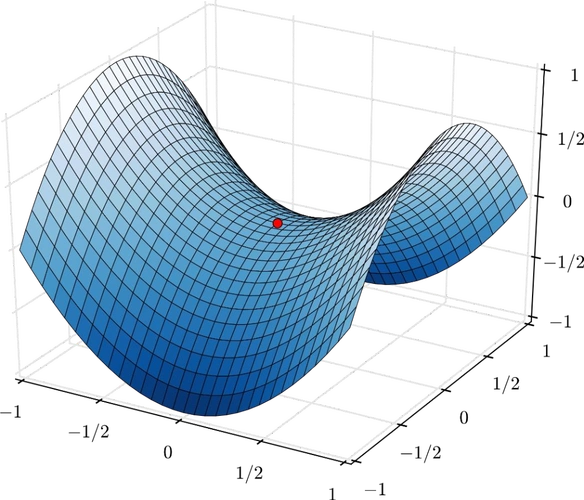

**关键性质**：
1. **对称性**：如果二阶偏导数连续，则 ∂²f/∂xᵢ∂xⱼ = ∂²f/∂xⱼ∂xᵢ（Clairaut定理）
2. **实对称矩阵**：可以正交对角化（特征值都是实数，特征向量正交）

**代码演示**

以下代码通过具体的二次函数`f(x,y) = x² + 2y² - 2xy + x - 2y`，验证 Hessian 矩阵在多元微积分与最优化理论中的核心性质。
1. 数学模型定义：定义了基础函数和它的Hessian矩阵
2. 可视化
- 左图（3D 视角）：你可以看到一个非常标准的“碗”形。因为 Hessian 矩阵是正定的（特征值  3 +- √5 均大于0），这个碗没有马鞍形的扭曲，也没有平坦的谷底，它是一个严格凸函数。红星标记的位置就是这个碗的最底端（全局极小值点）。
- 右图（2D 俯视视角）：等高线是一圈一圈的倾斜椭圆。在优化算法（如梯度下降）中，这种“拉长的椭圆”意味着不同方向上的曲率（陡峭程度）不同。如果沿着椭圆的长轴方向走，步长需要非常小；如果沿着短轴方向走，可以迈大步。这也是为什么在实际训练中，我们通常需要引入“动量（Momentum）”或“自适应学习率（如 Adam）”来修正这种各向异性。
3. Hessian 矩阵性质验证：对于二次函数来说，实际上只要算出其中任意一个点的特征值 > 0 就可以了。H是一个常数矩阵，它里面根本没有 x 和 y 变量。无论您代入(0,0),(0,1)还是(100,-50)，算出来的 Hessian 矩阵都是完全一样的，特征值自然也全都是大于 0 。

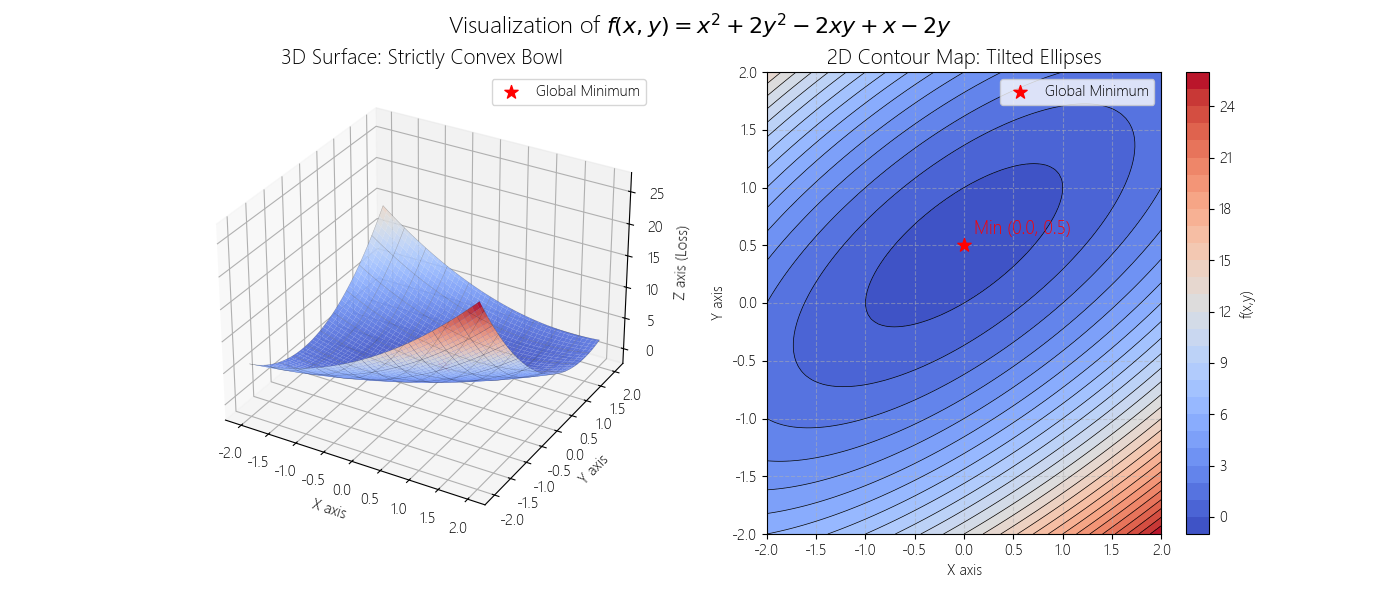

=== Hessian矩阵验证 ===
f(x,y) = x² + 2y² - 2xy + x - 2y
Hessian H = [[2, -2], [-2, 4]]（常数矩阵）

在点 (0, 0): 
  特征值: [0.76393202 5.23606798]
在点 (1, 1): 
  特征值: [0.76393202 5.23606798]
在点 (-1, 2): 
  特征值: [0.76393202 5.23606798]
在点 (3, -1): 
  特征值: [0.76393202 5.23606798]
  → 验证通过：所有特征值均 > 0，Hessian 是正定矩阵

→ 对于二次函数，Hessian是常数矩阵
→ 特征值都>0 → 正定 → 函数是严格凸函数


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================== 1. 数学模型定义 ======================
def f_2d(x, y):
    """f(x,y) = x² + 2y² - 2xy + x - 2y"""
    return x**2 + 2*y**2 - 2*x*y + x - 2*y

def hessian_f(x, y):
    """Hessian矩阵 (二阶导数)"""
    return np.array([[2.0, -2.0],
                     [-2.0,  4.0]])

# ====================== 2. 可视化 f_2d ======================
# 生成网格数据
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d(X, Y)

fig = plt.figure(figsize=(14, 6))

# --- 左图：3D 曲面图 ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='none')
# 叠加黑色网格线，增加立体感
ax1.plot_wireframe(X, Y, Z, color='black', linewidth=0.3, alpha=0.3, rstride=10, cstride=10)

# 寻找并标记全局极小值点
# 对于 f(x,y) = x² + 2y² - 2xy + x - 2y，令梯度为0，解得极小值点在 (0, 0.5)
min_x, min_y = 0.0, 0.5
min_z = f_2d(min_x, min_y)
ax1.scatter([min_x], [min_y], [min_z], color='red', s=100, marker='*', zorder=5, label='Global Minimum')

ax1.set_title('3D Surface: Strictly Convex Bowl', fontsize=14)
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Z axis (Loss)')
ax1.view_init(elev=30, azim=-60)
ax1.legend()

# --- 右图：2D 等高线图 (Top View) ---
ax2 = fig.add_subplot(122)
# 绘制填充等高线
contour = ax2.contourf(X, Y, Z, levels=30, cmap='coolwarm')
# 绘制等高线边框
ax2.contour(X, Y, Z, levels=30, colors='k', linewidths=0.5)
plt.colorbar(contour, ax=ax2, label='f(x,y)')

# 标记极小值点
ax2.scatter(min_x, min_y, color='red', s=100, marker='*', zorder=5, label='Global Minimum')
ax2.text(min_x + 0.1, min_y + 0.1, f'Min ({min_x}, {min_y})', fontsize=12, color='red')

ax2.set_title('2D Contour Map: Tilted Ellipses', fontsize=14)
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Visualization of $f(x,y) = x^2 + 2y^2 - 2xy + x - 2y$', fontsize=16)
# plt.tight_layout()
plt.show()

# ======================3. Hessian 矩阵性质验证 ======================
print("=== Hessian矩阵验证 ===")
print("f(x,y) = x² + 2y² - 2xy + x - 2y")
print("Hessian H = [[2, -2], [-2, 4]]（常数矩阵）\n")

test_points = [(0, 0), (1, 1), (-1, 2), (3, -1)]
for x0, y0 in test_points:
    H = hessian_f(x0, y0)
    eigenvals, eigenvecs = np.linalg.eig(H)
    
    # 使用 np.all() 确保【所有】特征值都严格大于 0
    is_positive_definite = np.all(eigenvals > 0)
    
    print(f"在点 ({x0}, {y0}): ")
    # print(f"  Hessian = \n{H}")
    print(f"  特征值: {eigenvals}")
    
if is_positive_definite:
    print(f"  → 验证通过：所有特征值均 > 0，Hessian 是正定矩阵\n")
else:
    print(f"  → 验证失败：存在非正特征值，Hessian 不是正定矩阵\n")

print("→ 对于二次函数，Hessian是常数矩阵")
print("→ 特征值都>0 → 正定 → 函数是严格凸函数")

---

## 三、Hessian的定性分析：正定、负定、不定

Hessian矩阵的**特征值**决定了函数在某点的局部形状：

| Hessian特征值 | 函数局部形状 | 优化意义 |
|---------------|---------------|-----------|
| **全部 > 0**（正定） | 局部**碗形**（concave up） | **局部最小值**候选 |
| **全部 < 0**（负定） | 局部**帽形**（concave down） | **局部最大值**候选 |
| **有正有负**（不定） | 局部**鞍点**（saddle point） | 不是极值点 |
| **有零特征值** | 平坦方向 | 退化情况 |

**在机器学习中的应用**：
- **梯度下降**只用到一阶信息（梯度），收敛速度慢（线性收敛）
- **牛顿法**用到二阶信息（Hessian），收敛速度快（二次收敛），但计算Hessian的代价高

**代码演示**
下面的代码通过数值计算与3D可视化相结合的方式，展示 Hessian 矩阵在多元函数极值判定中的核心作用。
1. Hessian 矩阵的数值计算（有限差分法）和 Hessian 矩阵的定性判定准则
2. 定义分别是正定、负定、不定的3个测试函数
3. 3D 可视化验证
   - 左图（正定）：一个开口向上的完美“碗”。所有方向上的曲率都是正的，Hessian 特征值全大于 0，中心红点是全局极小值点。
   - 中图（负定）：一个倒扣的“帽子”。所有方向上的曲率都是负的，Hessian 特征值全小于 0，中心红点是全局极大值点。
   - 右图（不定）：经典的“马鞍面”。在 X 轴方向向上弯曲（正曲率），在 Y 轴方向向下弯曲（负曲率）。Hessian 特征值一正一负，中心红点是鞍点（梯度为 0，但不是极值点）。
4. 输出分析结果

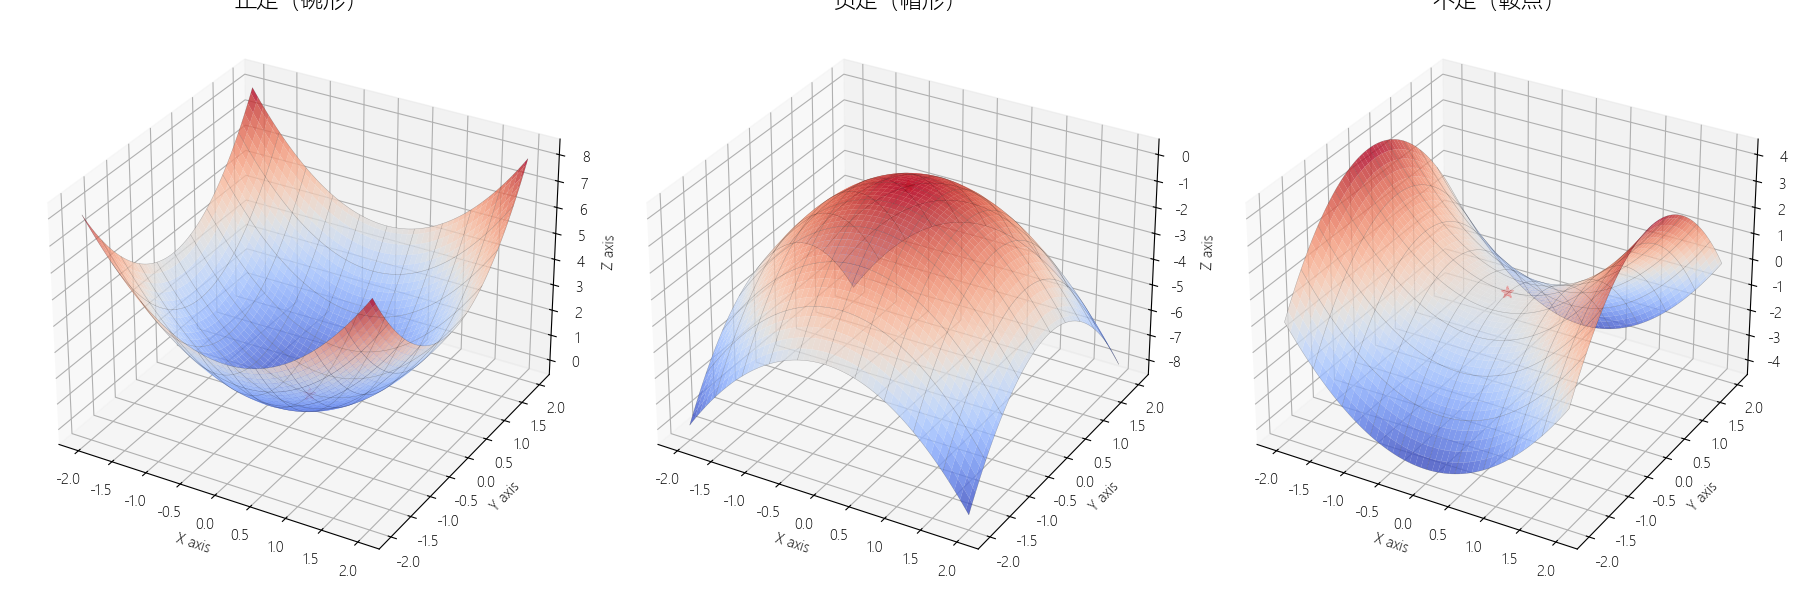

=== Hessian 定性分析 ===

函数: 正定（碗形）
  Hessian = 
[[2. 0.]
 [0. 2.]]
  特征值: [2. 2.]
  定性: 正定（Positive Definite）

函数: 负定（帽形）
  Hessian = 
[[-2.  0.]
 [ 0. -2.]]
  特征值: [-2. -2.]
  定性: 负定（Negative Definite）

函数: 不定（鞍点）
  Hessian = 
[[ 2.  0.]
 [ 0. -2.]]
  特征值: [ 2. -2.]
  定性: 不定（Indefinite）

→ 正定 → 局部最小值
→ 负定 → 局部最大值
→ 不定 → 鞍点（不是极值点）



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================== 1. Hessian 分析函数 ======================
def analyze_hessian(f, x0, y0):
    """分析函数在某点的Hessian定性（使用有限差分法）"""
    h = 1e-6
    f_xx = (f(x0+h, y0) - 2*f(x0, y0) + f(x0-h, y0)) / h**2
    f_yy = (f(x0, y0+h) - 2*f(x0, y0) + f(x0, y0-h)) / h**2
    f_xy = (f(x0+h, y0+h) - f(x0+h, y0-h) - f(x0-h, y0+h) + f(x0-h, y0-h)) / (4*h**2)
    
    H = np.array([[f_xx, f_xy], [f_xy, f_yy]])
    eigenvals, eigenvecs = np.linalg.eig(H)
    
    # 判断定性
    if np.all(eigenvals > 1e-8):
        定性 = "正定（Positive Definite）"
    elif np.all(eigenvals < -1e-8):
        定性 = "负定（Negative Definite）"
    elif np.any(eigenvals > 1e-8) and np.any(eigenvals < -1e-8):
        定性 = "不定（Indefinite）"
    else:
        定性 = "半正定/半负定（Degenerate）"
    
    return H, eigenvals, 定性

# ====================== 2. 测试函数定义 ======================
def f1(x, y):
    """正定：f(x,y) = x² + y²（碗形）"""
    return x**2 + y**2

def f2(x, y):
    """负定：f(x,y) = -(x² + y²)（帽形）"""
    return -(x**2 + y**2)

def f3(x, y):
    """不定：f(x,y) = x² - y²（鞍点）"""
    return x**2 - y**2

# ====================== 3. 3D 可视化代码 ======================
# 生成网格数据
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)

# 创建画布
fig = plt.figure(figsize=(18, 6))

# 遍历三个函数进行绘图
for i, (name, func) in enumerate(test_funcs):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    Z = func(X, Y)
    
    # 绘制半透明曲面 + 黑色网格线
    ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
    ax.plot_wireframe(X, Y, Z, color='black', linewidth=0.3, alpha=0.3, rstride=10, cstride=10)
    
    # 在中心点标记极值点或鞍点
    ax.scatter([0], [0], [func(0, 0)], color='red', s=80, marker='*', zorder=5)
    
    # 设置视角和标签
    ax.set_title(name, fontsize=16)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.view_init(elev=30, azim=-60)  # 统一观察视角，便于对比

plt.tight_layout()
plt.show()

# ====================== 4. 终端输出分析结果 ======================
print("=== Hessian 定性分析 ===\n")
test_funcs = [("正定（碗形）", f1), ("负定（帽形）", f2), ("不定（鞍点）", f3)]

for name, func in test_funcs:
    H, eigenvals, 定性 = analyze_hessian(func, 0, 0)
    print(f"函数: {name}")
    print(f"  Hessian = \n{H}")
    print(f"  特征值: {eigenvals}")
    print(f"  定性: {定性}\n")

print("→ 正定 → 局部最小值")
print("→ 负定 → 局部最大值")
print("→ 不定 → 鞍点（不是极值点）\n")

---

## 四、Hessian在优化中的应用：牛顿法

### 梯度下降 vs 牛顿法

**梯度下降（一阶方法）**：
$$w_{t+1} = w_t - \eta \cdot \nabla f(w_t)$$

**牛顿法（二阶方法）**：
$$w_{t+1} = w_t - H^{-1} \cdot \nabla f(w_t)$$

牛顿法用Hessian的逆矩阵来**调整更新方向**，考虑了函数的曲率信息。

**代码演示**

下面的代码通过一个简单的二次函数 f(x) = x²，对比了一阶优化算法（梯度下降）与二阶优化算法（牛顿法）在收敛速度上的巨大差异。
代码逻辑比较简单我就不写说明了。

=== 梯度下降 vs 牛顿法 ===
初始点: w₀ = 5.0
真实最小值: w* = 0

梯度下降（η=0.1）:
  迭代 10 次后: w = 0.536871
  损失: 0.2882303762

牛顿法:
  迭代 10 次后: w = 0.0000000000
  损失: 0.0000000000

→ 牛顿法收敛速度远快于梯度下降！
→ 对于二次函数，牛顿法一步就收敛到精确解！


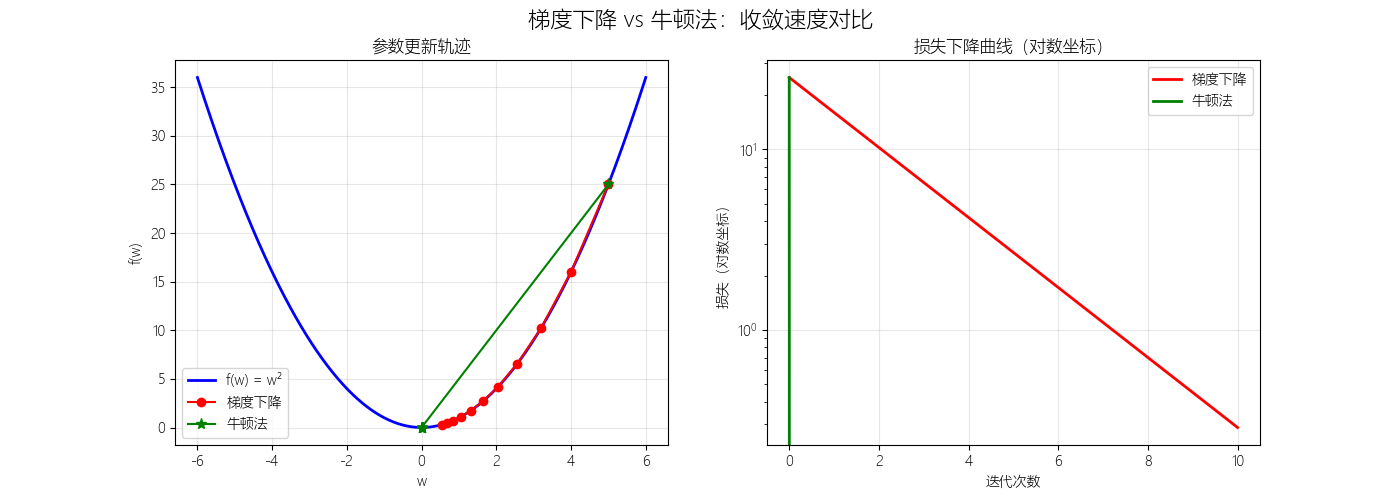

In [27]:
# 梯度下降 vs 牛顿法：收敛速度对比
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """f(x) = x²（简单二次函数）"""
    return x**2

def grad_f(x):
    """f'(x) = 2x"""
    return 2*x

def hessian_f(x):
    """f''(x) = 2（常数）"""
    return 2.0

# 梯度下降
def gradient_descent(start, learning_rate, n_iterations):
    """梯度下降：w := w - η * f'(w)"""
    w = start
    trajectory = [w]
    losses = [f(w)]
    
    for i in range(n_iterations):
        w = w - learning_rate * grad_f(w)
        trajectory.append(w)
        losses.append(f(w))
    
    return np.array(trajectory), np.array(losses)

# 牛顿法
def newton_method(start, n_iterations):
    """牛顿法：w := w - H⁻¹ * ∇f(w)"""
    w = start
    trajectory = [w]
    losses = [f(w)]
    
    for i in range(n_iterations):
        # 对于 f(x)=x²，H=2，所以 H⁻¹ = 0.5
        w = w - (1/hessian_f(w)) * grad_f(w)
        trajectory.append(w)
        losses.append(f(w))
    
    return np.array(trajectory), np.array(losses)

# 运行对比
start = 5.0
n_iterations = 10
learning_rate = 0.1

traj_gd, losses_gd = gradient_descent(start, learning_rate, n_iterations)
traj_nt, losses_nt = newton_method(start, n_iterations)

print("=== 梯度下降 vs 牛顿法 ===")
print(f"初始点: w₀ = {start}")
print(f"真实最小值: w* = 0")
print(f"\n梯度下降（η={learning_rate}）:")
print(f"  迭代 {n_iterations} 次后: w = {traj_gd[-1]:.6f}")
print(f"  损失: {losses_gd[-1]:.10f}")
print(f"\n牛顿法:")
print(f"  迭代 {n_iterations} 次后: w = {traj_nt[-1]:.10f}")
print(f"  损失: {losses_nt[-1]:.10f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：参数更新轨迹
w_range = np.linspace(-6, 6, 500)
axes[0].plot(w_range, f(w_range), 'b-', lw=2, label='f(w) = w²')
axes[0].plot(traj_gd, losses_gd, 'ro-', markersize=6, label='梯度下降')
axes[0].plot(traj_nt, losses_nt, 'g*-', markersize=8, label='牛顿法')
axes[0].set_xlabel('w')
axes[0].set_ylabel('f(w)')
axes[0].set_title('参数更新轨迹')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：损失下降曲线（对数坐标）
axes[1].semilogy(losses_gd, 'r-', lw=2, label='梯度下降')
axes[1].semilogy(losses_nt, 'g-', lw=2, label='牛顿法')
axes[1].set_xlabel('迭代次数')
axes[1].set_ylabel('损失（对数坐标）')
axes[1].set_title('损失下降曲线（对数坐标）')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('梯度下降 vs 牛顿法：收敛速度对比', fontsize=16)
plt.show()

这张对比图非常直观地展示了一阶优化算法（梯度下降）与二阶优化算法（牛顿法）在收敛性能上的巨大差异。
**左图：参数更新轨迹**
- 红色曲线（梯度下降）：呈现出明显的锯齿状震荡。由于梯度下降只利用了一阶导数（斜率）信息，它不知道函数的曲率，只能沿着当前最陡的方向前进。为了不掉出谷底，通常需要较小的学习率，导致它在接近极小值点时像“走迷宫”一样缓慢逼近，走了很多弯路。
- 绿色直线（牛顿法）：呈现出一步到位的直线轨迹。牛顿法利用了二阶导数（Hessian矩阵/曲率）信息，它不仅知道梯度的方向，还知道地面的弯曲程度。对于二次函数这种完美的抛物线，牛顿法能够计算出精确的步长，直接从起点跳跃到全局最小值点（ w=0 ）。

**右图：损失下降曲线（对数坐标）**
这张图量化了两种算法的收敛速度，Y轴采用了对数刻度，这意味着数值微小的变化都会被放大显示。
红色斜线（梯度下降）：表现为一条斜率固定的直线。在对数坐标下，直线意味着线性收敛。也就是说，每迭代一次，误差按固定的比例缩小（例如每次缩小一半）。虽然稳定，但需要很多次迭代才能达到高精度。
绿色垂直线（牛顿法）：表现为几乎垂直掉落的线条。这代表了超线性收敛或二次收敛。在第1次迭代后，损失值就已经从 10¹ 级别瞬间跌落至机器精度（接近 0 ），后续的迭代几乎没有变化。

牛顿法的更新公式本质上是用二次泰勒展开来近似原函数。
当原函数本身就是一个二次函数（如 f(x) = x² ）时，牛顿法的二次近似是完美且无误差的。因此，它算出的极小值点就是真实的全局极小值点，自然只需要一步就能到达终点。

虽然牛顿法收敛极快，但在实际深度学习工程中却很少直接使用，原因在于：
- 计算成本高：对于  N 维参数，计算 Hessian 矩阵需要  O(N²)的空间和计算量，求逆矩阵更是需要 O(N³)。当神经网络有上亿参数时，这在计算上是完全不可行的。
- Hessian 可能不定：在非凸的损失函数中，Hessian 矩阵可能是负定或不定的（即存在鞍点或极大值）。此时 H⁻¹ 会导致算法向极大值方向更新，从而引发发散。这也是为什么实际应用中多采用拟牛顿法（如 L-BFGS）或一阶自适应算法（如 Adam）。

---

## 📝 本篇小结

| 概念 | 数学定义 | 在优化中的角色 |
|------|---------|-----------|
| **二阶导数** | f''(x) = d²f/dx² | 曲率信息（函数的弯曲程度） |
| **Hessian矩阵** | Hᵢⱼ = ∂²f/∂xᵢ∂xⱼ | 二阶偏导数的集合（d×d矩阵） |
| **正定矩阵** | 所有特征值 > 0 | 局部最小值候选 |
| **负定矩阵** | 所有特征值 < 0 | 局部最大值候选 |
| **牛顿法** | w := w - H⁻¹·∇f | 用曲率信息加速收敛（二次收敛） |

## 🏋️ 课后挑战

1. **推导Hessian矩阵**：对于 f(x,y) = e^{-(x²+y²)}，手工计算Hessian矩阵，并用代码数值验证。
2. **实现牛顿法**：对于一个非凸函数（如 f(x) = x⁴ - 4x² + 5），用牛顿法优化，观察是否会收敛到局部最大值（因为Hessian可能负定）。

> 下期预告：凸函数与凸优化基础 —— 为什么「凸」这么重要？